<a href="https://colab.research.google.com/github/Innovatewithapple/NeuralNetwork/blob/main/CNNPractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from keras.models import Sequential
from keras.layers import Dense,Input,MaxPool2D,Flatten,Conv2D
from keras.utils import to_categorical
from keras.datasets import mnist

import numpy as np
from sklearn.metrics import classification_report

import cv2
import matplotlib.pyplot as plt

In [2]:
(x_train,y_train), (x_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
#reshape
x_train = x_train.reshape(-1,28,28,1).astype('float32')
x_test = x_test.reshape(-1,28,28,1).astype('float32')

In [5]:
#Normalization
x_train = x_train / 255
x_test = x_test / 255

In [6]:
num_classes = len(np.unique(y_train))
num_classes

10

In [7]:
#categorical target
y_train = to_categorical(y_train,num_classes)
y_test = to_categorical(y_test,num_classes)

In [8]:
#model
model = Sequential()
model.add(Input(shape=(28,28,1)))
model.add(Conv2D(filters=16,kernel_size=(5,5),strides=(1,1),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2),strides=(1,1)))
model.add(Flatten())
model.add(Dense(100,activation='relu'))
model.add(Dense(num_classes,activation='softmax'))

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

model.fit(x_train,y_train,batch_size=500,epochs=10,validation_split=0.2,verbose=2)

Epoch 1/10
96/96 - 5s - 54ms/step - accuracy: 0.9042 - loss: 0.3298 - val_accuracy: 0.9651 - val_loss: 0.1238
Epoch 2/10
96/96 - 1s - 7ms/step - accuracy: 0.9737 - loss: 0.0893 - val_accuracy: 0.9794 - val_loss: 0.0742
Epoch 3/10
96/96 - 1s - 7ms/step - accuracy: 0.9827 - loss: 0.0593 - val_accuracy: 0.9822 - val_loss: 0.0649
Epoch 4/10
96/96 - 1s - 7ms/step - accuracy: 0.9874 - loss: 0.0447 - val_accuracy: 0.9833 - val_loss: 0.0574
Epoch 5/10
96/96 - 1s - 7ms/step - accuracy: 0.9896 - loss: 0.0359 - val_accuracy: 0.9827 - val_loss: 0.0581
Epoch 6/10
96/96 - 1s - 7ms/step - accuracy: 0.9910 - loss: 0.0297 - val_accuracy: 0.9852 - val_loss: 0.0517
Epoch 7/10
96/96 - 1s - 7ms/step - accuracy: 0.9928 - loss: 0.0240 - val_accuracy: 0.9846 - val_loss: 0.0583
Epoch 8/10
96/96 - 1s - 7ms/step - accuracy: 0.9948 - loss: 0.0186 - val_accuracy: 0.9868 - val_loss: 0.0457
Epoch 9/10
96/96 - 1s - 7ms/step - accuracy: 0.9958 - loss: 0.0148 - val_accuracy: 0.9882 - val_loss: 0.0458
Epoch 10/10
96/96 

In [ ]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred,axis=1)
y_test_classes = np.argmax(y_test,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
print('classification Report: ',classification_report(y_test_classes,y_pred_classes))

classification Report:                precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.98      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [62]:
img = cv2.imread('/content/IMG_2503.jpeg')

In [63]:
#converting it to grayscale
img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

In [64]:
#resize it to 28x28
img = cv2.resize(img,(28,28))

In [65]:
#invert colors because mnist trained data need black background of image
img = 255 - img

In [66]:
#normalize it
img = img / 255

In [67]:
#reshape
img = img.reshape(1,28,28,1)

TypeError: Invalid shape (1, 28, 28, 1) for image data

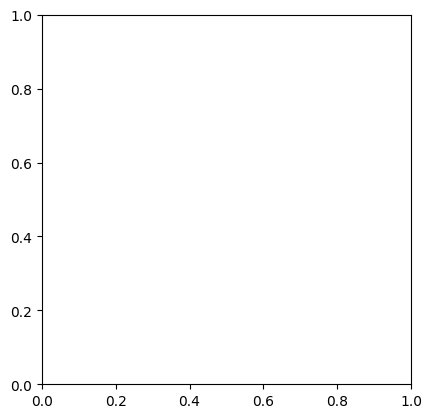

In [68]:
plt.imshow(img, cmap='gray')
plt.title("Final Image")
plt.show()

In [69]:
pred = model.predict(img)
print("Prediction:", np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
Prediction: 8


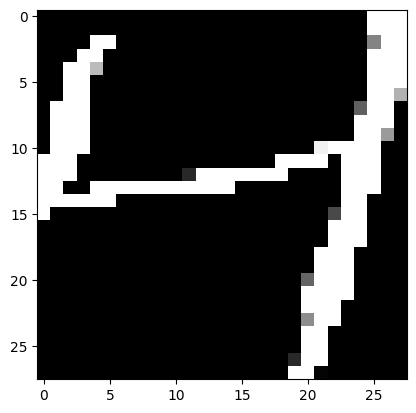

In [70]:
img = cv2.imread('/content/IMG_2503.jpeg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 🔥 Blur to remove noise
gray = cv2.GaussianBlur(gray, (5,5), 0)

# 🔥 Otsu threshold
_, thresh = cv2.threshold(gray, 0, 255,
                          cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 🔥 Find digit contour
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Get biggest contour (your digit)
cnt = max(contours, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(cnt)
digit = thresh[y:y+h, x:x+w]

# 🔥 Resize to 28x28
digit = cv2.resize(digit, (28,28))

digit = digit / 255.0

plt.imshow(digit, cmap='gray')
plt.show()

digit = digit.reshape(1,28,28,1)

In [71]:
fourpredict = model.predict(digit)
print("predicted number: ",np.argmax(fourpredict))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
predicted number:  7
